In [16]:
import xarray as xr

ds = xr.open_dataset("tigge_2014-11-01_0012.grib", engine="cfgrib")

print("Variables in this file:", list(ds.data_vars))
print("Coordinates:", ds.coords)


df = ds.to_dataframe()
print(df.head())


Variables in this file: ['t2m']
Coordinates: Coordinates:
  * time               (time) datetime64[ns] 16B 2014-11-01 2014-11-01T12:00:00
  * step               (step) timedelta64[ns] 32B 00:00:00 06:00:00 ... 18:00:00
  * latitude           (latitude) float64 168B 70.0 68.0 66.0 ... 34.0 32.0 30.0
  * longitude          (longitude) float64 288B 230.0 232.0 ... 298.0 300.0
    number             int64 8B ...
    heightAboveGround  float64 8B ...
    valid_time         (time, step) datetime64[ns] 64B ...
                                      number  heightAboveGround valid_time  \
time       step   latitude longitude                                         
2014-11-01 0 days 70.0     230.0           1                2.0 2014-11-01   
                           232.0           1                2.0 2014-11-01   
                           234.0           1                2.0 2014-11-01   
                           236.0           1                2.0 2014-11-01   
                       

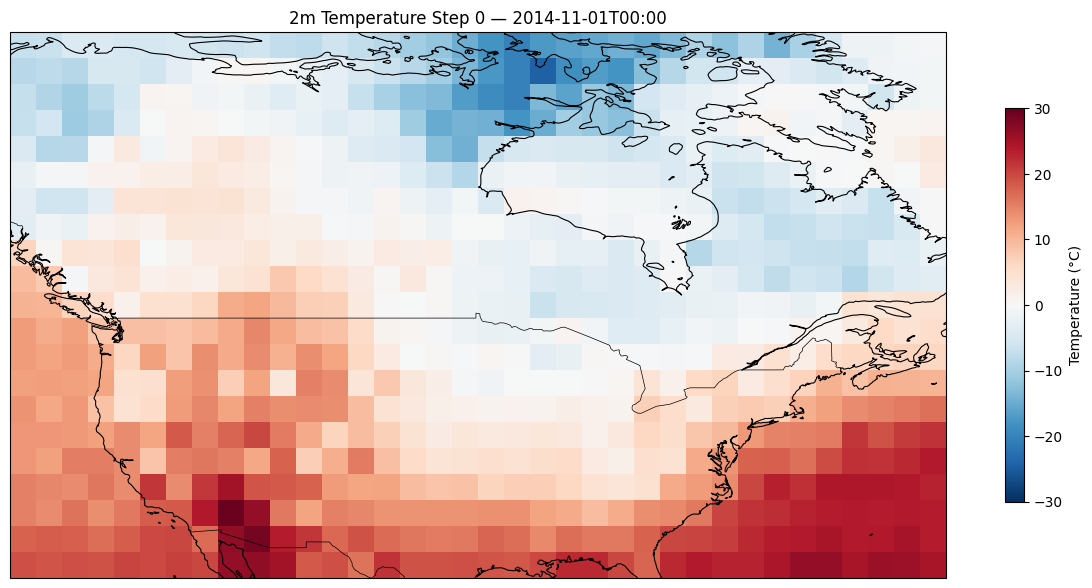

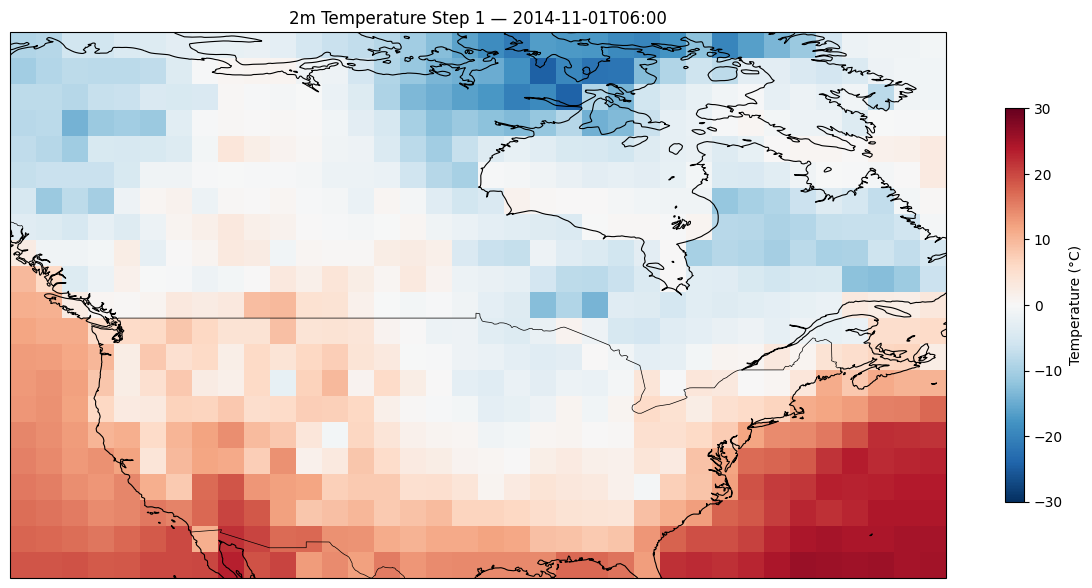

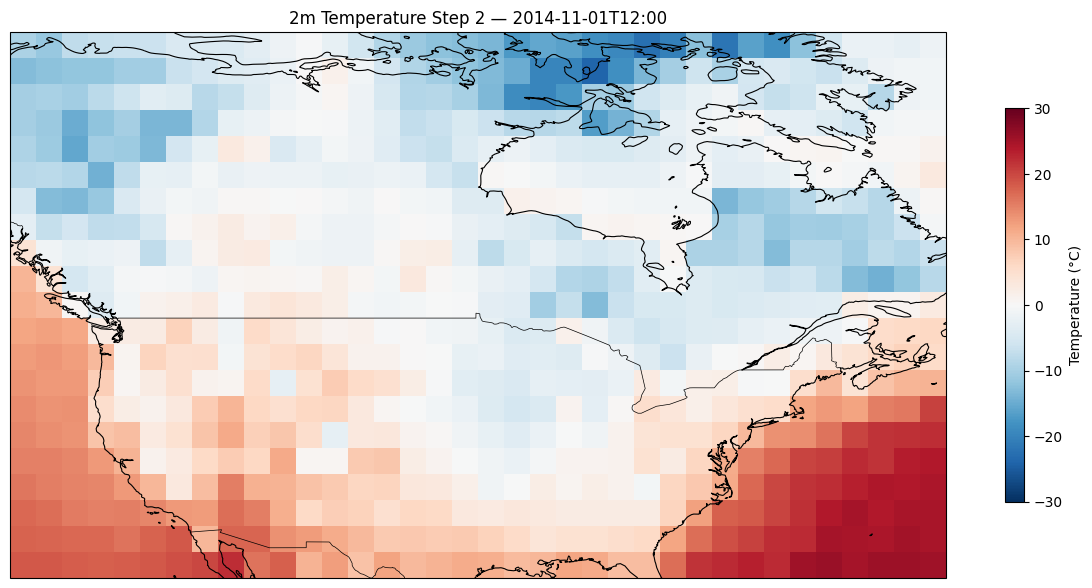

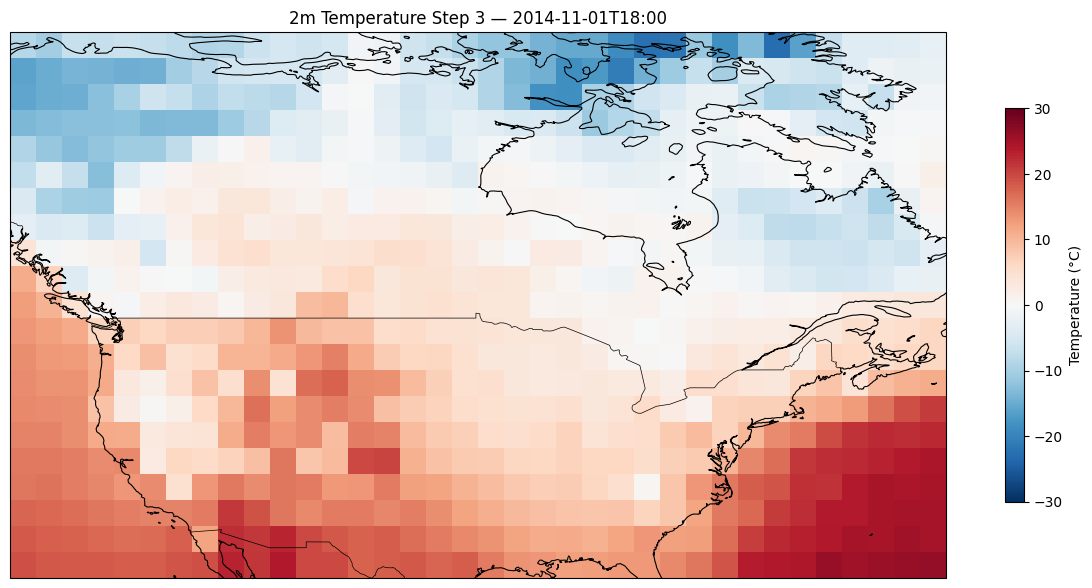

In [19]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Load data
ds = xr.open_dataset("tigge_2014-11-01_0012.grib", engine="cfgrib")
t2m = ds['t2m']

# Convert to Celsius
t2m_celsius = t2m - 273.15

# Pick one time slice to plot (first run, first step)
t2m_slice = t2m_celsius.isel(time=0, step=0)

for i, step in enumerate(ds.step):
    t2m_slice = t2m_celsius.isel(time=0, step=i)

# Plot
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

    im = ax.pcolormesh(
        t2m_slice.longitude,
        t2m_slice.latitude,
        t2m_slice.values,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin=-30, vmax=30
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, alpha=0.1)

    plt.colorbar(im, ax=ax, label='Temperature (°C)', shrink=0.7)
    ax.set_title(f"2m Temperature Step {i} — {str(t2m_slice.valid_time.values)[:16]}")

    plt.tight_layout()
    plt.show()